# RetailPulse - Week 2 Checkpoint

## AI-Powered Customer Analytics & Demand Forecasting Platform

### Week 2 Objectives
- Hybrid Forecasting Model (Prophet + LSTM Ensemble)
- Churn Prediction with XGBoost + SHAP Explainability
- Inventory Optimization Logic
- Feature Importance Analysis and Optuna Hyperparameter Tuning
- Drift Detection Setup (Evidently AI)
- Automated Retraining Pipeline (Airflow)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Week 2 Deliverables

In [2]:
ensemble_forecast = pd.read_csv("../data/ensemble_forecast_results.csv")

ensemble_future = pd.read_csv("../data/ensemble_future_30_days.csv")

ensemble_metrics = pd.read_csv("../data/ensemble_metrics.csv")

churn_predictions = pd.read_csv("../data/churn_predictions_tuned.csv")

churn_metrics = pd.read_csv("../data/churn_metrics.csv")

tuning_summary = pd.read_csv("../data/optuna_tuning_summary.csv")

best_params = pd.read_csv("../data/optuna_best_params.csv")

inventory_projection = pd.read_csv("../data/inventory_projection.csv")

inventory_summary = pd.read_csv("../data/inventory_summary.csv")

drift_columns = pd.read_csv("../data/drift_column_results.csv")

drift_summary = pd.read_csv("../data/drift_monitor_summary.csv")

retraining_log = pd.read_csv("../data/retraining_log.csv")

## Dataset Summary

In [3]:
print("Ensemble Forecast Shape:")
print(ensemble_forecast.shape)

print("\nEnsemble Future Forecast Shape:")
print(ensemble_future.shape)

print("\nChurn Predictions Shape:")
print(churn_predictions.shape)

print("\nInventory Projection Shape:")
print(inventory_projection.shape)

Ensemble Forecast Shape:
(275, 5)

Ensemble Future Forecast Shape:
(30, 4)

Churn Predictions Shape:
(4338, 15)

Inventory Projection Shape:
(30, 5)


## Day 8: Hybrid Forecasting (Prophet + LSTM Ensemble)

In [4]:
ensemble_metrics

,Model,MAPE,RMSE
0,Prophet,0.322256,13269.136332
1,LSTM,0.525403,18290.839075
2,Ensemble,0.318187,13331.635635


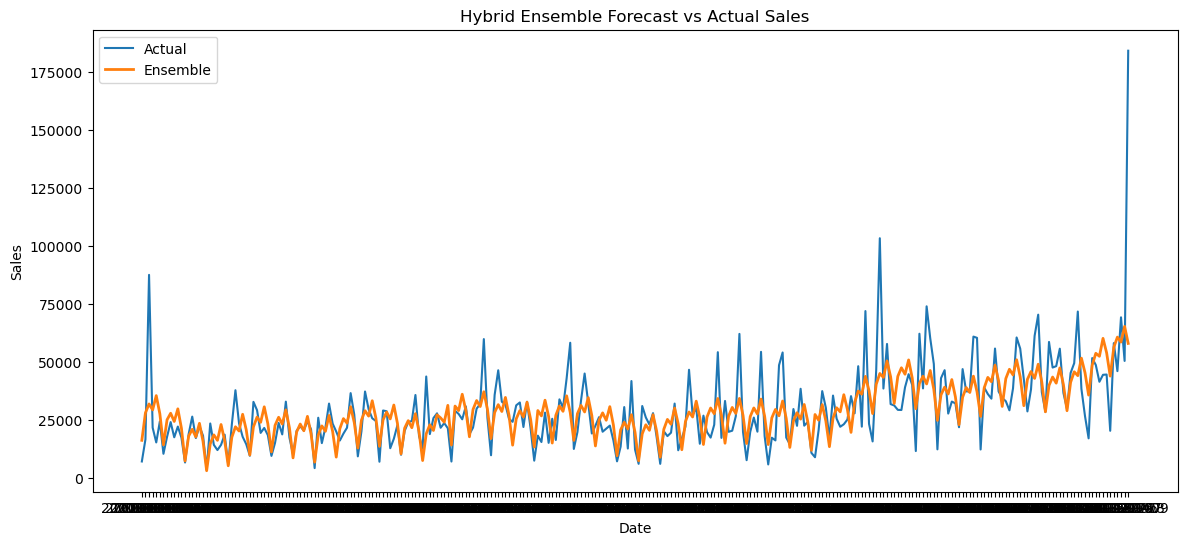

In [5]:
valid_final = ensemble_forecast.dropna(subset=["actual"])

plt.figure(figsize=(14,6))

plt.plot(valid_final["ds"], valid_final["actual"], label="Actual")
plt.plot(valid_final["ds"], valid_final["ensemble_yhat"], label="Ensemble", linewidth=2)

plt.title("Hybrid Ensemble Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

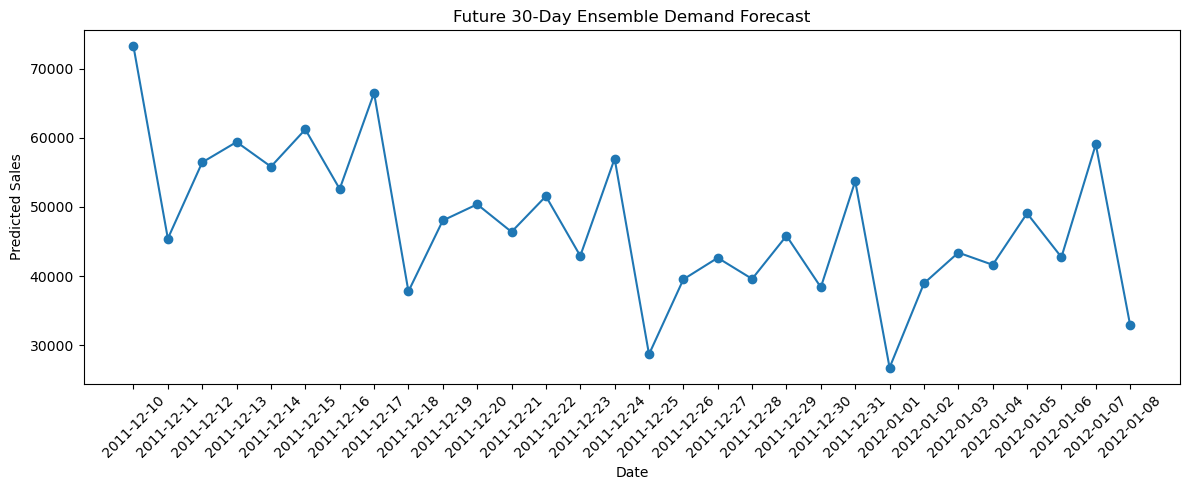

In [6]:
plt.figure(figsize=(12,5))

plt.plot(ensemble_future["ds"], ensemble_future["ensemble_yhat"], marker="o")

plt.title("Future 30-Day Ensemble Demand Forecast")

plt.xlabel("Date")
plt.ylabel("Predicted Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Day 9 & 11: Churn Prediction (XGBoost + SHAP + Optuna Tuning)

In [7]:
churn_metrics

,Metric,Value
0,AUC-ROC,1.0
1,Precision@Top20%,1.0
2,Churn Threshold (days),142.0


In [8]:
tuning_summary

,Metric,Value
0,Baseline AUC-ROC,1.000000
1,Tuned AUC-ROC,0.999958
2,Improvement,-0.000042
3,Precision@Top20% (Tuned),1.000000
4,Best CV AUC (Optuna),0.999999
5,Number of Trials,30.000000


In [9]:
best_params

,Parameter,Value
0,n_estimators,454.000000
1,max_depth,10.000000
2,learning_rate,0.073768
3,subsample,0.895934
4,colsample_bytree,0.724681
5,min_child_weight,6.000000
6,gamma,2.378903
7,reg_alpha,0.512482
8,reg_lambda,0.376535


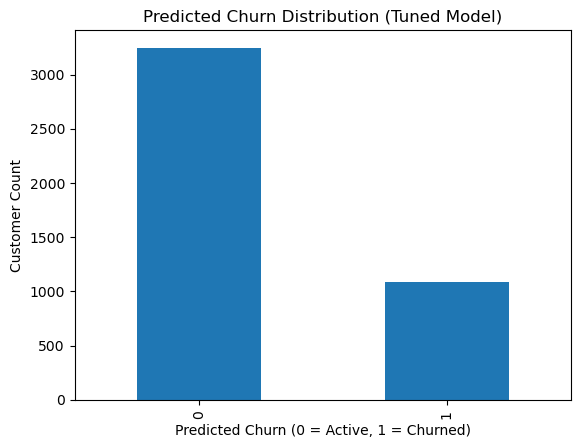

In [10]:
churn_predictions["PredictedChurn_Tuned"].value_counts().plot(kind="bar")

plt.title("Predicted Churn Distribution (Tuned Model)")

plt.xlabel("Predicted Churn (0 = Active, 1 = Churned)")
plt.ylabel("Customer Count")

plt.show()

## Day 10: Inventory Optimization

In [11]:
inventory_summary

,Metric,Value
0,Average Daily Demand,29138.45
1,Std Dev Daily Demand,17835.46
2,Lead Time (days),7.00
3,Service Level Z-score,1.65
4,Safety Stock,77860.53
5,Reorder Point,281829.67
6,Assumed Current Stock,437076.73
7,Total Forecasted Demand (30d),1427548.16
8,Recommended Order Quantity,1068331.96
9,Overstock Ceiling,563659.34


In [12]:
inventory_projection["StockStatus"].value_counts()

StockStatus
Understock Risk    28
Optimal             2
Name: count, dtype: int64

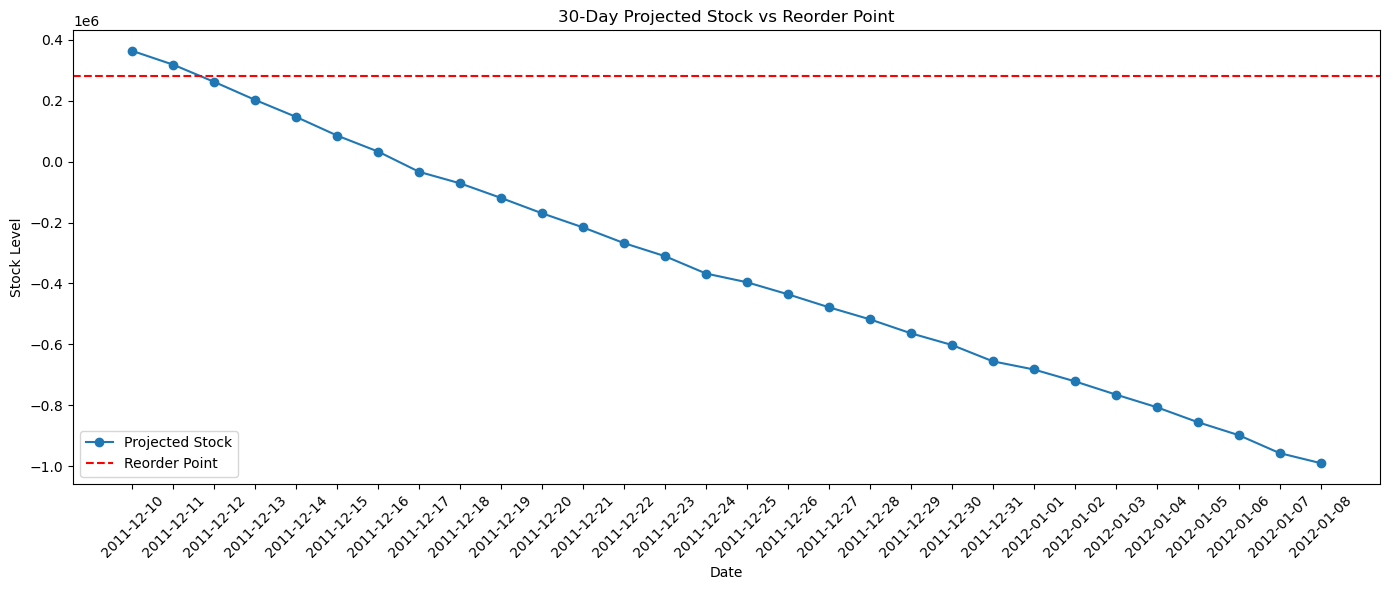

In [13]:
reorder_point = inventory_summary.loc[
    inventory_summary["Metric"] == "Reorder Point", "Value"
].values[0]

plt.figure(figsize=(14,6))

plt.plot(inventory_projection["ds"], inventory_projection["ProjectedStock"], marker="o", label="Projected Stock")

plt.axhline(reorder_point, color="red", linestyle="--", label="Reorder Point")

plt.title("30-Day Projected Stock vs Reorder Point")

plt.xlabel("Date")
plt.ylabel("Stock Level")

plt.xticks(rotation=45)

plt.legend()

plt.tight_layout()

plt.show()

## Day 12 & 13: Drift Detection and Retraining Pipeline

In [14]:
drift_columns

,column,drift_score_p_value,drift_detected
0,AvgOrderValue,0.016620,True
1,ChurnProbability_Tuned,0.017963,True
2,UniqueProducts,0.032115,True
3,Frequency,0.040141,True
4,AvgCustomerFrequency,0.040141,True
5,TotalQuantity,0.044316,True
6,Monetary,0.072113,False
7,Recency,0.250040,False


In [15]:
drift_summary

,Metric,Value
0,Drifted Columns Count,1
1,Total Monitored Columns,8
2,Drift Share,0.125
3,Retrain Threshold,0.5
4,Retraining Recommended,False


In [16]:
retraining_log

,timestamp,drift_share,retrain_triggered,new_model_auc,min_auc_threshold,passed_threshold,model_promoted
0,2026-06-13T12:10:07.047709,0.125,False,NaN,NaN,NaN,NaN


## Consolidated Model Performance vs Targets

In [17]:
ensemble_mape = ensemble_metrics.loc[
    ensemble_metrics["Model"] == "Ensemble", "MAPE"
].values[0]

tuned_auc = tuning_summary.loc[
    tuning_summary["Metric"] == "Tuned AUC-ROC", "Value"
].values[0]

precision_top20 = tuning_summary.loc[
    tuning_summary["Metric"] == "Precision@Top20% (Tuned)", "Value"
].values[0]

targets_df = pd.DataFrame({
    "Metric": [
        "Demand Forecast MAPE (Ensemble)",
        "Churn AUC-ROC (Tuned)",
        "Churn Precision@Top20% (Tuned)"
    ],
    "Target": [
        "<= 0.12",
        ">= 0.88",
        ">= 0.75"
    ],
    "Achieved": [
        ensemble_mape,
        tuned_auc,
        precision_top20
    ]
})

targets_df["Met"] = [
    targets_df["Achieved"][0] <= 0.12,
    targets_df["Achieved"][1] >= 0.88,
    targets_df["Achieved"][2] >= 0.75
]

targets_df

,Metric,Target,Achieved,Met
0,Demand Forecast MAPE (Ensemble),<= 0.12,0.318187,False
1,Churn AUC-ROC (Tuned),>= 0.88,0.999958,True
2,Churn Precision@Top20% (Tuned),>= 0.75,1.000000,True


In [18]:
targets_df.to_csv("../data/week2_targets_summary.csv", index=False)

print("Week 2 targets summary saved")

Week 2 targets summary saved


# Week 2 Achievements

### Completed Tasks

1. Built a hybrid Prophet + LSTM ensemble forecasting model (Day 8), found the optimal blending weight, and generated a 30-day future demand forecast.

2. Trained an XGBoost churn prediction model with SHAP explainability (Day 9):
   - Defined churn label based on Recency distribution analysis
   - Engineered behavioral features (AvgOrderValue, UniqueProducts, TotalQuantity, AvgCustomerFrequency)
   - Applied SMOTE to balance classes

3. Built inventory optimization logic (Day 10):
   - Calculated safety stock and reorder point
   - Projected 30-day stock depletion using forecasted demand
   - Generated reorder quantity recommendations and overstock/understock classification

4. Tuned the churn model with Optuna (Day 11):
   - Ran a 30-trial hyperparameter search with 5-fold cross-validation
   - Compared baseline vs tuned AUC-ROC and Precision@Top20%
   - Analyzed feature importance with XGBoost and SHAP

5. Set up drift detection with Evidently AI (Day 12):
   - Simulated reference vs current data batches
   - Identified drifted features and computed an overall drift share
   - Defined a retraining decision rule

6. Built an automated retraining pipeline (Day 13):
   - Implemented drift check -> conditional retrain -> evaluate/promote -> log as reusable functions
   - Generated an Airflow DAG (`retraining_dag.py`) for daily scheduled execution

### Models & Artifacts Saved

- `models/lstm_model_ensemble.pth` - Hybrid ensemble LSTM
- `models/xgb_churn_model_tuned.json` - Tuned XGBoost churn model
- `models/xgb_churn_model_retrained.json` - Retraining pipeline output
- `data/ensemble_forecast_results.csv`, `ensemble_future_30_days.csv`, `ensemble_metrics.csv`
- `data/churn_predictions_tuned.csv`, `churn_metrics.csv`, `optuna_tuning_summary.csv`, `optuna_best_params.csv`
- `data/inventory_projection.csv`, `inventory_summary.csv`
- `data/drift_column_results.csv`, `drift_monitor_summary.csv`, `retraining_log.csv`
- `data/week2_targets_summary.csv`
- `reports/data_drift_report.html`, `data_summary_report.html`
- `pipeline_tasks.py`, `retraining_dag.py`

### Next Steps (Week 3)

- Build the Streamlit dashboard skeleton (Day 15)
- Add demand forecasting visualizations and what-if analysis (Day 16)
- Add customer segmentation and churn risk dashboard (Day 17)
- Add inventory optimization recommendations UI (Day 18)